In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

In [3]:
df = pd.read_csv(r"C:\Users\User\Desktop\ML\Data\processed\maharashtra_model_ready.csv")

In [4]:
df = df.drop(df.filter(like="Unnamed:").columns, axis=1)

In [5]:
target_columns = ['target_1m_ahead', 'target_2m_ahead', 'target_3m_ahead']

In [6]:
# 3. Define features and target
features_exclude = ['future_drought_class', 'target_1m_ahead', 'target_2m_ahead', 'target_3m_ahead', 'month', 'district', 'date']
feature_columns = [col for col in df.columns if col not in features_exclude]


In [7]:
X = df[feature_columns]
y = df['target_1m_ahead']

print("Feature names:", feature_columns)
print("Target distribution:\n", y.value_counts())

Feature names: ['year', 'rainfall_mm', 'SoilMoi_0_10', 'SoilMoi_10_40', 'SoilMoi_40_100', 'SoilMoi_100_200', 'et_mean_mm', 'ndvi', 'mean_temp_c', 'ndvi_anomaly', 'SoilMoi_0_10_pct', 'SoilMoi_10_40_pct', 'SoilMoi_40_100_pct', 'SoilMoi_100_200_pct', 'ndvi_roll3', 'SoilMoi_0_10_roll3', 'SoilMoi_10_40_roll3', 'SoilMoi_40_100_roll3', 'SoilMoi_100_200_roll3', 'rainfall_mm_lag1', 'rainfall_mm_lag2', 'rainfall_mm_lag3', 'ndvi_lag1', 'ndvi_lag2', 'ndvi_lag3', 'SoilMoi_0_10_lag1', 'SoilMoi_0_10_lag2', 'SoilMoi_0_10_lag3', 'et_mean_mm_lag1', 'et_mean_mm_lag2', 'et_mean_mm_lag3', 'rainfall_roll3', 'rainfall_roll6', 'month_sin', 'month_cos']
Target distribution:
 target_1m_ahead
No Drought    2342
Extreme       1113
Moderate       360
Name: count, dtype: int64


In [8]:
train_year = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_year = [2022, 2023, 2024]

train_mask = df['year'].isin(train_year)
test_mask = df['year'].isin(test_year)

In [9]:
X_train = X[train_mask]
X_test = X[test_mask]

y_1m_train = y[train_mask]
y_1m_test = y[test_mask]

In [10]:
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("\nClass distribution in Training set:")
print(y_1m_train.value_counts())
print("\nClass distribution in Test set:")
print(y_1m_test.value_counts())

Training set shape: (2765, 35)
Test set shape: (1050, 35)

Class distribution in Training set:
target_1m_ahead
No Drought    1610
Extreme        877
Moderate       278
Name: count, dtype: int64

Class distribution in Test set:
target_1m_ahead
No Drought    732
Extreme       236
Moderate       82
Name: count, dtype: int64


In [11]:
#district label_encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['district_encoded'] = le.fit_transform(df['district'])

In [12]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_1m_train)

print("Before SMOTE:", pd.Series(y_1m_train).value_counts())
print("After SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Before SMOTE: target_1m_ahead
No Drought    1610
Extreme        877
Moderate       278
Name: count, dtype: int64
After SMOTE:
 target_1m_ahead
No Drought    1610
Moderate      1610
Extreme       1610
Name: count, dtype: int64



 Final Test Classification Report:
              precision    recall  f1-score   support

     Extreme       0.77      0.89      0.82       236
    Moderate       0.41      0.23      0.30        82
  No Drought       0.93      0.93      0.93       732

    accuracy                           0.87      1050
   macro avg       0.70      0.68      0.68      1050
weighted avg       0.86      0.87      0.86      1050



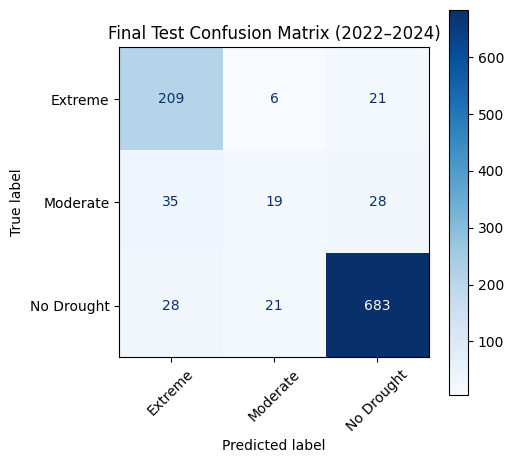

In [13]:
#Apply SMOTE to full training set (2015–2021)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_1m_train)

# Train RF on resampled set
model_rf_smote = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)
model_rf_smote.fit(X_train_resampled, y_train_resampled)

# Predict on hold-out test (2022–2024)
y_1m_pred_rf_smote = model_rf_smote.predict(X_test)

print("\n Final Test Classification Report:")
print(classification_report(y_1m_test, y_1m_pred_rf_smote))

# Confusion Matrix for test set
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_1m_test, y_1m_pred_rf_smote,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Final Test Confusion Matrix (2022–2024)")
plt.show()


In [14]:
joblib.dump(model_rf_smote, "rf_smote_best.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [15]:
from sklearn.metrics import accuracy_score, f1_score
metrics = {
    "accuracy": accuracy_score(y_1m_test, y_1m_pred_rf_smote),
    "f1_macro": f1_score(y_1m_test, y_1m_pred_rf_smote, average="macro")
}
import json
json.dump(metrics, open("rf_smote_metrics.json", "w"))


In [16]:
import joblib

# X = features used to train RF
rf_features_order = X.columns.tolist()  # get column names in order

# Save feature order to a file
joblib.dump(rf_features_order, "rf_features_order.pkl")
print("✅ RF feature order saved!")


✅ RF feature order saved!
